# References
https://github.com/tintn/vision-transformer-from-scratch

In [1]:
dataset_root = './datasets'
print('Will store datasets in', dataset_root)

import os
cpu_num = os.cpu_count() // 2
print('Dataloaders will use {} CPUs'.format(cpu_num))

Will store datasets in ./datasets
Dataloaders will use 8 CPUs


In [2]:
import random

import torch
import torch.utils.data as tud
import torch.nn as nn
import torch.nn.functional as F

import torchvision.transforms as tvt
import torchvision.transforms.v2 as tv2
import torchvision.transforms.functional as tvf
import torchvision.datasets as tds
import torchvision.utils as tu
import torchinfo

from tqdm import tqdm
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'

/home/kyle/mambaforge/envs/ml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
train_tfs = tvt.Compose([
    tv2.ToImage(),
    tv2.RandomCrop(32, 4),
    tv2.RandomHorizontalFlip(0.5),
    tv2.RandomVerticalFlip(0.25),
    tv2.ToDtype(torch.float32, scale=True),
    tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_tfs = tvt.Compose([
    tv2.ToImage(),
    tv2.ToDtype(torch.float32, scale=True),
    tv2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

cifar_train = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=True,
    transform=train_tfs,
)
cifar_eval = tds.CIFAR10(
    root=dataset_root,
    download=True,
    train=False,
    transform=val_tfs,
)
cifar_train = tds.wrap_dataset_for_transforms_v2(cifar_train)
cifar_eval = tds.wrap_dataset_for_transforms_v2(cifar_eval)

Files already downloaded and verified
Files already downloaded and verified


In [4]:
batchsize = 32

train_loader = tud.DataLoader(cifar_train, batch_size=batchsize, num_workers=cpu_num, shuffle=True)
val_loader = tud.DataLoader(cifar_eval, batch_size=batchsize, shuffle=True)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


torch.Size([64, 3, 32, 32]) tensor(-0.1934)


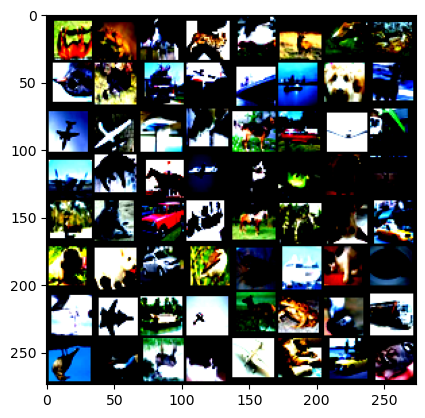

In [5]:
def random_grid(imgs, sz: int):
    grid = tu.make_grid(imgs)
    return grid.permute(1, 2, 0)

num=64
augmented = torch.stack([x[0] for x in random.choices(cifar_train, k=num)])
print(augmented.shape, augmented.mean())
tmps = random_grid(augmented, num)
plt.imshow(tmps.cpu())

In [6]:
# Input B C H W
class Tokenizer(nn.Module):
    def __init__(self, c_in, emb_len, patch_dim):
        super().__init__()
        self.conv0 = nn.Conv2d(c_in, emb_len, patch_dim, stride=patch_dim)
    
    def forward(self, x):
        x = self.conv0(x)
        x = x.flatten(2)
        x = x.permute(0, 2, 1)
        return x

# Input B, (P * P), C
class Embeddings(nn.Module):
    def __init__(self, emb_len, patch_num, dropout=0.1):
        super().__init__()
        self.cls_token = nn.Parameter(torch.randn(1, 1, emb_len))
        self.pos_emb = nn.Parameter(
            torch.randn(1, patch_num + 1, emb_len)
        )
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, x):
        b, p2, c = x.shape
        
        cls_tok = self.cls_token.expand(b, -1, -1)
        x = torch.cat((cls_tok, x), dim=1)
        x = x + self.pos_emb # I think pos_emb is automatically broadcast in the batch dimension here.
        x = self.dropout(x)
        return x

class Transformer(nn.Module):
    def __init__(self, emb_len, patch_num, layers=8, heads=4, dim_ff=512, dropout=0.1):
        super().__init__()
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_len,
            nhead=heads,
            dim_feedforward=dim_ff,
            dropout=dropout,
            batch_first=True # <-- This took me forever to find, default is to place batch in the second dimension
        )
        self.transformer = nn.TransformerEncoder(
            encoder_layer,
            num_layers=layers,
        )
    
    def forward(self, x):
        y = self.transformer(x)
        return y

class ClassHead(nn.Module):
    def __init__(self, emb_len, patch_num, hidden_sz, classes, dropout=0.1):
        super().__init__()
        self.fc0 = nn.Linear(emb_len, hidden_sz)
        self.activation = nn.ReLU()
        self.fc1 = nn.Linear(hidden_sz, classes)
        self.dropout = nn.Dropout(dropout)
    
    def forward(self, inp):
        x = inp[:, 0, :]
        x = self.fc0(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.fc1(x)

        return x

class VIT(nn.Module):
    def __init__(self, num_classes, patchsz, emb_dim, layers=4, heads=4, dim_ff=64, load=None):
        super().__init__()
        self.tokenizer = Tokenizer(3, emb_dim, patchsz)
        self.embeddings = Embeddings(emb_dim, patch_num, 0.1) # 400 = (640 / 32)^2
        self.transformer = Transformer(emb_dim, patch_num + 1, layers=layers, heads=heads, dim_ff=dim_ff)
        self.class_head = ClassHead(emb_dim, patch_num + 1, 256, num_classes)
        if load and os.path.isfile(load):
            print(f"Will load weights from {load}")
            self.load_state_dict(torch.load(load))

    def forward(self, x):
        x = self.tokenizer(x)
        x = self.embeddings(x)
        x = self.transformer(x)
        x = self.class_head(x)
        return x

    def save(self, name='vit_classification.pth'):
        torch.save(self.state_dict(), name)

In [7]:
%%time

# This config gets ~ 70% accuracy on CIFAR10
imgsz = 32  # Images are this many pixels tall and wide in CIFAR10
patchsz = 2 # Patchsize of 2 results in 16x16 patches. patchsz=4 seems fine too.
emb_dim = 256  # AKA dmodel. Try reduce this if it takes too long to train.
patch_num = (imgsz // patchsz)**2
vit = VIT(
    10,
    patchsz,
    emb_dim,
    layers=4,
    heads=4,
    dim_ff=128,
    load='vit_classification.pth'  # Set to the saved model path to start from a checkpoint.
).to(device)

epochs = 50
optimizer = torch.optim.AdamW(vit.parameters(), lr=1e-4)
lossfn = nn.CrossEntropyLoss()

loss_plot = []
for epoch in range(epochs):
    vit.train()
    for i, (images, target) in enumerate(tqdm(train_loader)):
        optimizer.zero_grad()
        images = images.float().to(device)
        targets = target.to(device)

        outs = vit(images)
        loss = lossfn(outs, targets)
        loss.backward()
        optimizer.step()

    losses = []
    vit.eval()
    correct = 0
    total = len(cifar_eval)
    for i, (images, target) in enumerate(tqdm(val_loader)):
        with torch.no_grad():
            images = images.float().to(device)
            targets = target.to(device)
            outs = vit(images)
            loss = lossfn(outs, targets)
            losses.append(loss)
            for x in range(outs.shape[0]):
                preds = F.softmax(outs, dim=1)
                cls = preds[x].argmax()
                lbl = targets[x]
                if cls == lbl:
                    correct += 1

    epoch_loss = torch.Tensor(losses).mean().item()
    print("Epoch {}, Current loss is {}".format(epoch, epoch_loss))
    print("{}/{} correct, {:.2f}%".format(correct, total, 100*correct/total))
    loss_plot.append(epoch_loss)

plt.plot(loss_plot)

100%|█████████████████████████████████████████| 313/313 [00:06<00:00, 49.95it/s]


Epoch 0, Current loss is 1.6944599151611328
3781/10000 correct, 37.81%


100%|█████████████████████████████████████████| 313/313 [00:06<00:00, 50.26it/s]


Epoch 1, Current loss is 1.538097858428955
4422/10000 correct, 44.22%


100%|█████████████████████████████████████████| 313/313 [00:06<00:00, 48.81it/s]


...

Epoch 54, Current loss is 0.8600966930389404
7054/10000 correct, 70.54%


100%|█████████████████████████████████████████| 313/313 [00:06<00:00, 50.12it/s]


Epoch 55, Current loss is 0.8180481791496277
7191/10000 correct, 71.91%


  5%|█▉                                       | 76/1563 [00:05<01:42, 14.54it/s]


KeyboardInterrupt: 

100%|████████████████████████████████████| 10000/10000 [00:11<00:00, 872.11it/s]


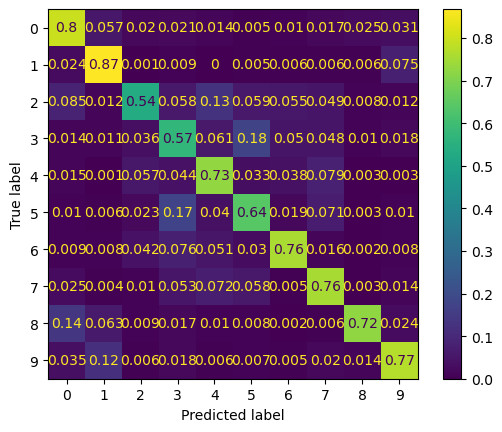

In [8]:
# !pip install scikit-learn 
from sklearn import metrics

evals = cifar_eval
right = 0; total = 0; y_pred=[]; y_true=[]

vit.eval()
with torch.no_grad():
    for image, target in tqdm(evals):
        pred = vit(image.unsqueeze(0).float().to(device))
        pred = F.softmax(pred, dim=1).argmax()
        
        y_pred.append(pred.item())
        y_true.append(target)

metrics.ConfusionMatrixDisplay.from_predictions(y_true, y_pred, normalize='true')

Here are your CIFAR10 classes for reference
```
0:"Airplane"
1:"Automobile"
2:"Bird"
3:"Cat"
4:"Deer"
5:"Dog"
6:"Frog"
7:"Horse"
8:"Ship"
9:"Truck"
```

In [9]:
vit.save()